# IM2HEIGHT Dataset Variant Configuration

This notebook is designed to work with different variants of the DFC2023 dataset, including:

- **DFC2023Amini**: The original Amini dataset variant
- **DFC2023S**: Small dataset variant
- **DFC2023A**: Alternative dataset variant 
- Any other variant with the same file structure

## Usage Instructions

1. Set the `dataset_name` variable in the configuration cell to match your dataset variant
2. The notebook will automatically load the correct paths for:
   - Dataset location
   - Prediction files
   - Visualization outputs
3. All visualizations and metrics will be computed for the specified dataset

The dataset structure should follow the standard DFC2023 format with `/test/rgb/` and `/test/dsm/` directories.

# IM2HEIGHT Results Visualization

This notebook visualizes the results from the IM2HEIGHT model, comparing:
1. Input RGB images
2. Ground truth DSM (Digital Surface Model)
3. Predicted DSM from the model

We'll load samples from the test dataset and their corresponding predictions to evaluate the model's performance. This notebook supports different DFC2023 dataset variants (DFC2023Amini, DFC2023S, DFC2023A, etc.) with the same file structure.

In [14]:
# Import required libraries
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
from PIL import Image
import torch
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error

# Add parent directory to path so we can import from the main project
sys.path.append('..')
from dfc2023_data import DFC2023Dataset

## Load Data

Let's set up the paths and load the test data. We'll load:
- RGB images from the test dataset
- Ground truth DSM from the test dataset
- Predicted DSM from the predictions folder

In [15]:
# Configure paths and dataset settings
# Change this variable to match the specific dataset variant you're using
dataset_name = "DFC2023Amini"  # Options: "DFC2023Amini", "DFC2023S", "DFC2023A", etc.

# Set up paths based on dataset name
dataset_path = f"/home/asfand/Ahmad/datasets/{dataset_name}"
predictions_path = f"/home/asfand/Ahmad/IM2HEIGHT/predictions/{dataset_name}"
output_dir = "/home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs"
os.makedirs(output_dir, exist_ok=True)  # Create output directory if it doesn't exist

# Load test dataset
test_dataset = DFC2023Dataset(dataset_path, 'test', 'rgb', 'dsm')

# Get list of prediction files
prediction_files = sorted([f for f in os.listdir(predictions_path) 
                         if f.endswith('_pred.npy') and os.path.isfile(os.path.join(predictions_path, f))])

print(f"Using dataset: {dataset_name}")
print(f"Found {len(prediction_files)} prediction files")
print(f"Test dataset contains {len(test_dataset)} samples")

Using dataset: DFC2023Amini
Found 8 prediction files
Test dataset contains 8 samples


In [16]:
# Analyze the dataset characteristics
def analyze_dataset(dataset_path, dataset_name):
    """Analyze the characteristics of the dataset and return summary information"""
    summary = {}
    summary['name'] = dataset_name
    
    # Check directories
    splits = ['train', 'valid', 'test']
    data_types = ['rgb', 'dsm', 'sar', 'sem']
    
    for split in splits:
        split_path = os.path.join(dataset_path, split)
        if not os.path.exists(split_path):
            continue
            
        summary[f'{split}_total'] = 0
        
        for dtype in data_types:
            type_path = os.path.join(split_path, dtype)
            if os.path.exists(type_path):
                files = [f for f in os.listdir(type_path) if os.path.isfile(os.path.join(type_path, f))]
                summary[f'{split}_{dtype}'] = len(files)
                if dtype == 'rgb' or dtype == 'dsm':  # Count these for total
                    summary[f'{split}_total'] = max(summary[f'{split}_total'], len(files))
    
    return summary

# Get dataset characteristics
dataset_info = analyze_dataset(dataset_path, dataset_name)

print(f"\nDataset Characteristics for {dataset_name}:")
print(f"Path: {dataset_path}")
for split in ['train', 'valid', 'test']:
    if f'{split}_total' in dataset_info:
        print(f"  {split.capitalize()} set: {dataset_info[f'{split}_total']} samples")
        for dtype in ['rgb', 'dsm', 'sar', 'sem']:
            if f'{split}_{dtype}' in dataset_info:
                print(f"    - {dtype.upper()}: {dataset_info[f'{split}_{dtype}']} files")

# Save dataset info for future comparison
os.makedirs(os.path.join(output_dir, 'dataset_info'), exist_ok=True)
dataset_info_file = os.path.join(output_dir, 'dataset_info', f"{dataset_name}_info.txt")

with open(dataset_info_file, 'w') as f:
    f.write(f"Dataset: {dataset_name}\n")
    f.write(f"Path: {dataset_path}\n")
    for k, v in dataset_info.items():
        if k != 'name':
            f.write(f"{k}: {v}\n")

print(f"\nDataset info saved to {dataset_info_file}")


Dataset Characteristics for DFC2023Amini:
Path: /home/asfand/Ahmad/datasets/DFC2023Amini
  Train set: 20 samples
    - RGB: 20 files
    - DSM: 20 files
    - SAR: 20 files
    - SEM: 20 files
  Valid set: 4 samples
    - RGB: 4 files
    - DSM: 4 files
    - SAR: 4 files
    - SEM: 4 files
  Test set: 8 samples
    - RGB: 8 files
    - DSM: 8 files
    - SAR: 8 files
    - SEM: 8 files

Dataset info saved to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/dataset_info/DFC2023Amini_info.txt


## Visualization Helper Functions

Let's define helper functions to visualize the RGB images, ground truth DSMs, and predicted DSMs.

In [17]:
def normalize_array(arr):
    """Normalize array to 0-1 range for visualization"""
    min_val = np.min(arr)
    max_val = np.max(arr)
    if max_val == min_val:
        return np.zeros_like(arr)
    return (arr - min_val) / (max_val - min_val)

def resize_array(arr, target_shape):
    """Resize array to match target shape"""
    from skimage.transform import resize
    return resize(arr, target_shape, mode='constant', anti_aliasing=True)

def visualize_sample(rgb_img, gt_dsm, pred_dsm, sample_name, save_fig=True):
    """
    Visualize a sample with RGB image, ground truth DSM, and predicted DSM.
    
    Args:
        rgb_img: RGB image tensor (C×H×W)
        gt_dsm: Ground truth DSM tensor (C×H×W)
        pred_dsm: Predicted DSM array (H×W)
        sample_name: Name of the sample for the figure title
        save_fig: Whether to save the figure
    """
    # Convert tensors to numpy and prepare for visualization
    rgb_np = rgb_img.permute(1, 2, 0).numpy()  # Convert to H×W×C for display
    
    # If RGB values are outside [0, 1], normalize them
    if rgb_np.max() > 1.0 or rgb_np.min() < 0.0:
        rgb_np = normalize_array(rgb_np)
    
    # Extract channel 0 from ground truth DSM if it's multi-channel
    if isinstance(gt_dsm, torch.Tensor):
        gt_dsm_np = gt_dsm[0].numpy() if gt_dsm.dim() > 2 else gt_dsm.numpy()
    else:
        gt_dsm_np = gt_dsm[0] if gt_dsm.ndim > 2 else gt_dsm
    
    # Extract the height values from the prediction (might need adjustment based on exact format)
    if pred_dsm.ndim > 2:
        pred_dsm_np = pred_dsm[0] if pred_dsm.shape[0] == 1 else pred_dsm
    else:
        pred_dsm_np = pred_dsm

    # Print the shapes for debugging
    print(f"RGB shape: {rgb_np.shape}")
    print(f"Ground truth DSM shape: {gt_dsm_np.shape}")
    print(f"Predicted DSM shape: {pred_dsm_np.shape}")
    
    # Ensure ground truth and prediction have the same shape for metrics calculation
    if gt_dsm_np.shape != pred_dsm_np.shape:
        print(f"Resizing prediction to match ground truth shape: {gt_dsm_np.shape}")
        pred_dsm_np = resize_array(pred_dsm_np, gt_dsm_np.shape)
        print(f"After resizing, predicted DSM shape: {pred_dsm_np.shape}")

    # Calculate error metrics
    try:
        mse = mean_squared_error(gt_dsm_np, pred_dsm_np)
        ssim_val = ssim(gt_dsm_np, pred_dsm_np, data_range=pred_dsm_np.max() - pred_dsm_np.min())
        error_map = gt_dsm_np - pred_dsm_np
        metrics_str = f"MSE: {mse:.4f}, SSIM: {ssim_val:.4f}"
    except Exception as e:
        print(f"Error calculating metrics: {e}")
        mse = ssim_val = float('nan')
        error_map = np.zeros_like(gt_dsm_np)
        metrics_str = "Metrics calculation failed"
    
    # Create colormap for height maps
    elevation_cmap = cm.terrain
    error_cmap = cm.RdBu_r
    
    # Create figure with 2x2 subplots
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    
    # RGB image
    axs[0, 0].imshow(rgb_np)
    axs[0, 0].set_title('RGB Input Image')
    axs[0, 0].axis('off')
    
    # Ground truth DSM
    gt_img = axs[0, 1].imshow(gt_dsm_np, cmap=elevation_cmap)
    axs[0, 1].set_title('Ground Truth DSM')
    axs[0, 1].axis('off')
    plt.colorbar(gt_img, ax=axs[0, 1], fraction=0.046, pad=0.04)
    
    # Predicted DSM
    pred_img = axs[1, 0].imshow(pred_dsm_np, cmap=elevation_cmap)
    axs[1, 0].set_title(f'Predicted DSM')
    axs[1, 0].axis('off')
    plt.colorbar(pred_img, ax=axs[1, 0], fraction=0.046, pad=0.04)
    
    # Error map
    error_img = axs[1, 1].imshow(error_map, cmap=error_cmap)
    axs[1, 1].set_title(f'Error Map ({metrics_str})')
    axs[1, 1].axis('off')
    plt.colorbar(error_img, ax=axs[1, 1], fraction=0.046, pad=0.04)
    
    # Overall title
    plt.suptitle(f'Sample: {sample_name}', fontsize=16)
    plt.tight_layout()
    
    # Save figure if requested
    if save_fig:
        output_path = os.path.join(output_dir, f"{sample_name}_comparison.png")
        plt.savefig(output_path, dpi=200, bbox_inches='tight')
        print(f"Saved visualization to {output_path}")
    
    return fig

## Visualization of Test Samples

Now let's visualize a few samples from the test dataset along with their predictions.

In [18]:
# Match prediction files with test samples
results = []

# Collect matching samples and predictions
for i, (img_tensor, label_tensor) in enumerate(test_dataset):
    # Get the sample basename (e.g., "SV_Berlin_52.5054_13.4804")
    input_path = test_dataset.input_files[i]
    sample_basename = os.path.splitext(os.path.basename(input_path))[0]
    
    # Find the corresponding prediction file
    pred_filename = f"{sample_basename}_pred.npy"
    pred_path = os.path.join(predictions_path, pred_filename)
    
    if os.path.exists(pred_path):
        pred_dsm = np.load(pred_path)
        results.append({
            'sample_name': sample_basename,
            'rgb_img': img_tensor,
            'gt_dsm': label_tensor,
            'pred_dsm': pred_dsm
        })
    else:
        print(f"Warning: No prediction found for {sample_basename}")

print(f"Found {len(results)} matching samples with predictions")

Found 8 matching samples with predictions


## Display Sample Results

Let's visualize the first few test samples.

RGB shape: (512, 512, 3)
Ground truth DSM shape: (512, 512)
Predicted DSM shape: (512, 512)
Saved visualization to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/SV_Berlin_52.5054_13.4804_comparison.png


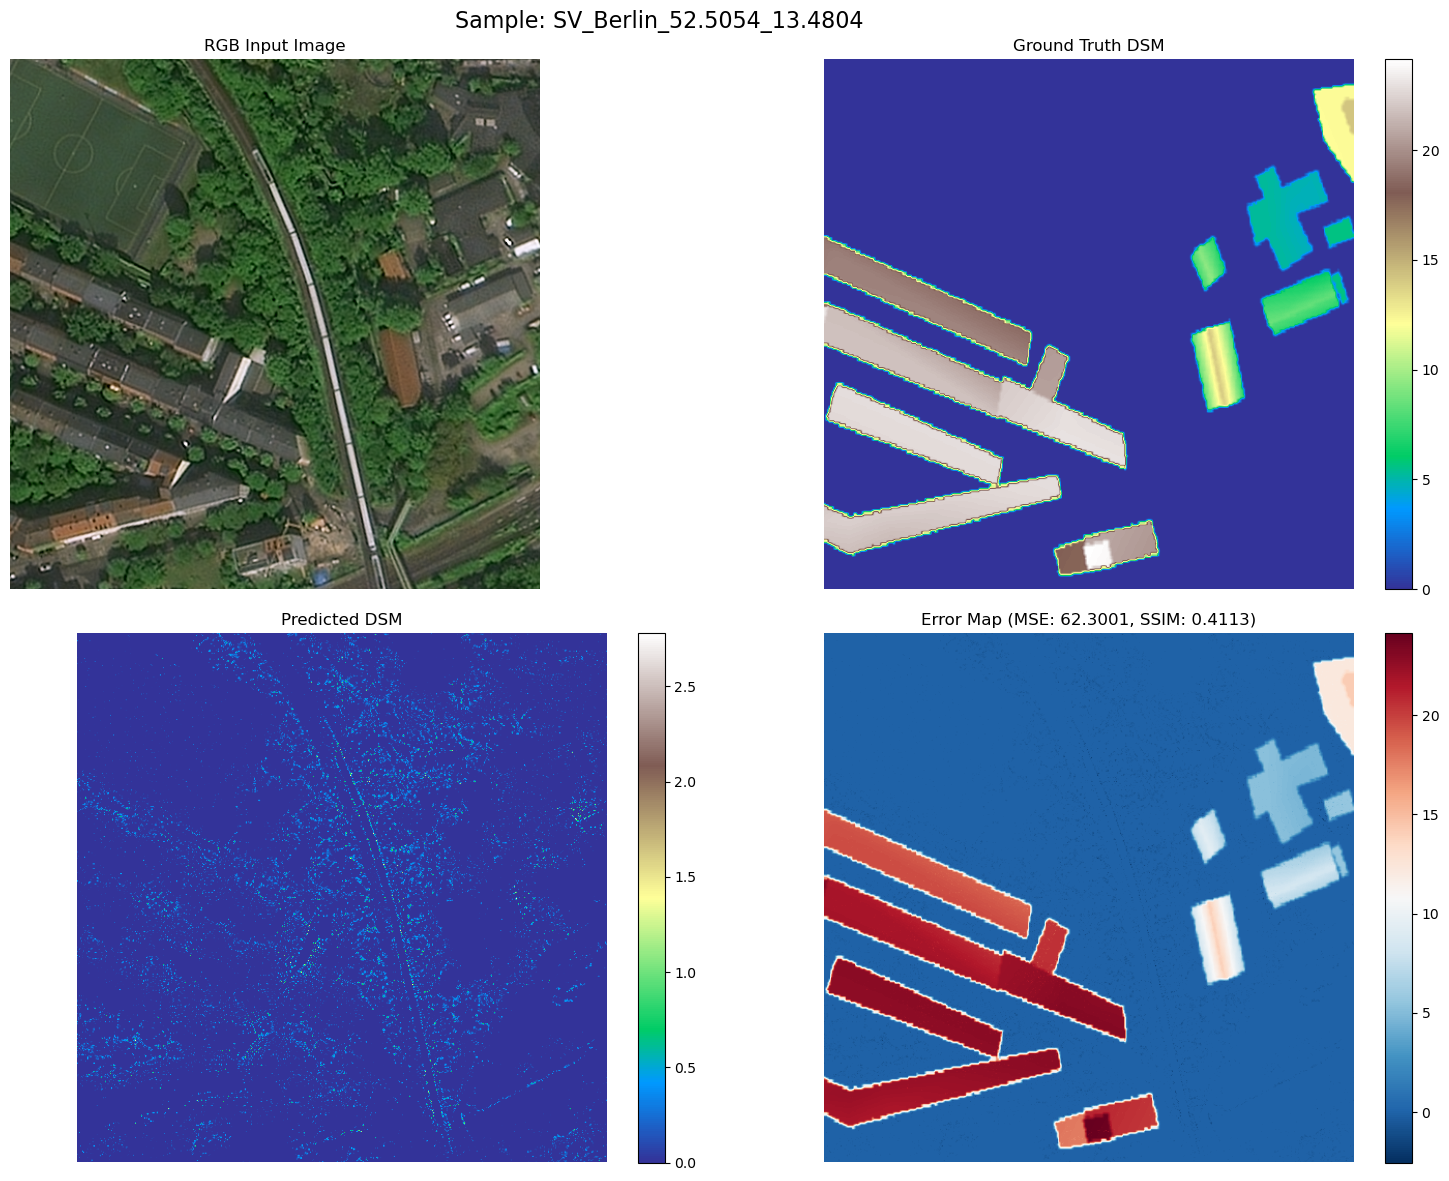

RGB shape: (512, 512, 3)
Ground truth DSM shape: (512, 512)
Predicted DSM shape: (512, 512)
Saved visualization to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/SV_Berlin_52.5286_13.4557_comparison.png


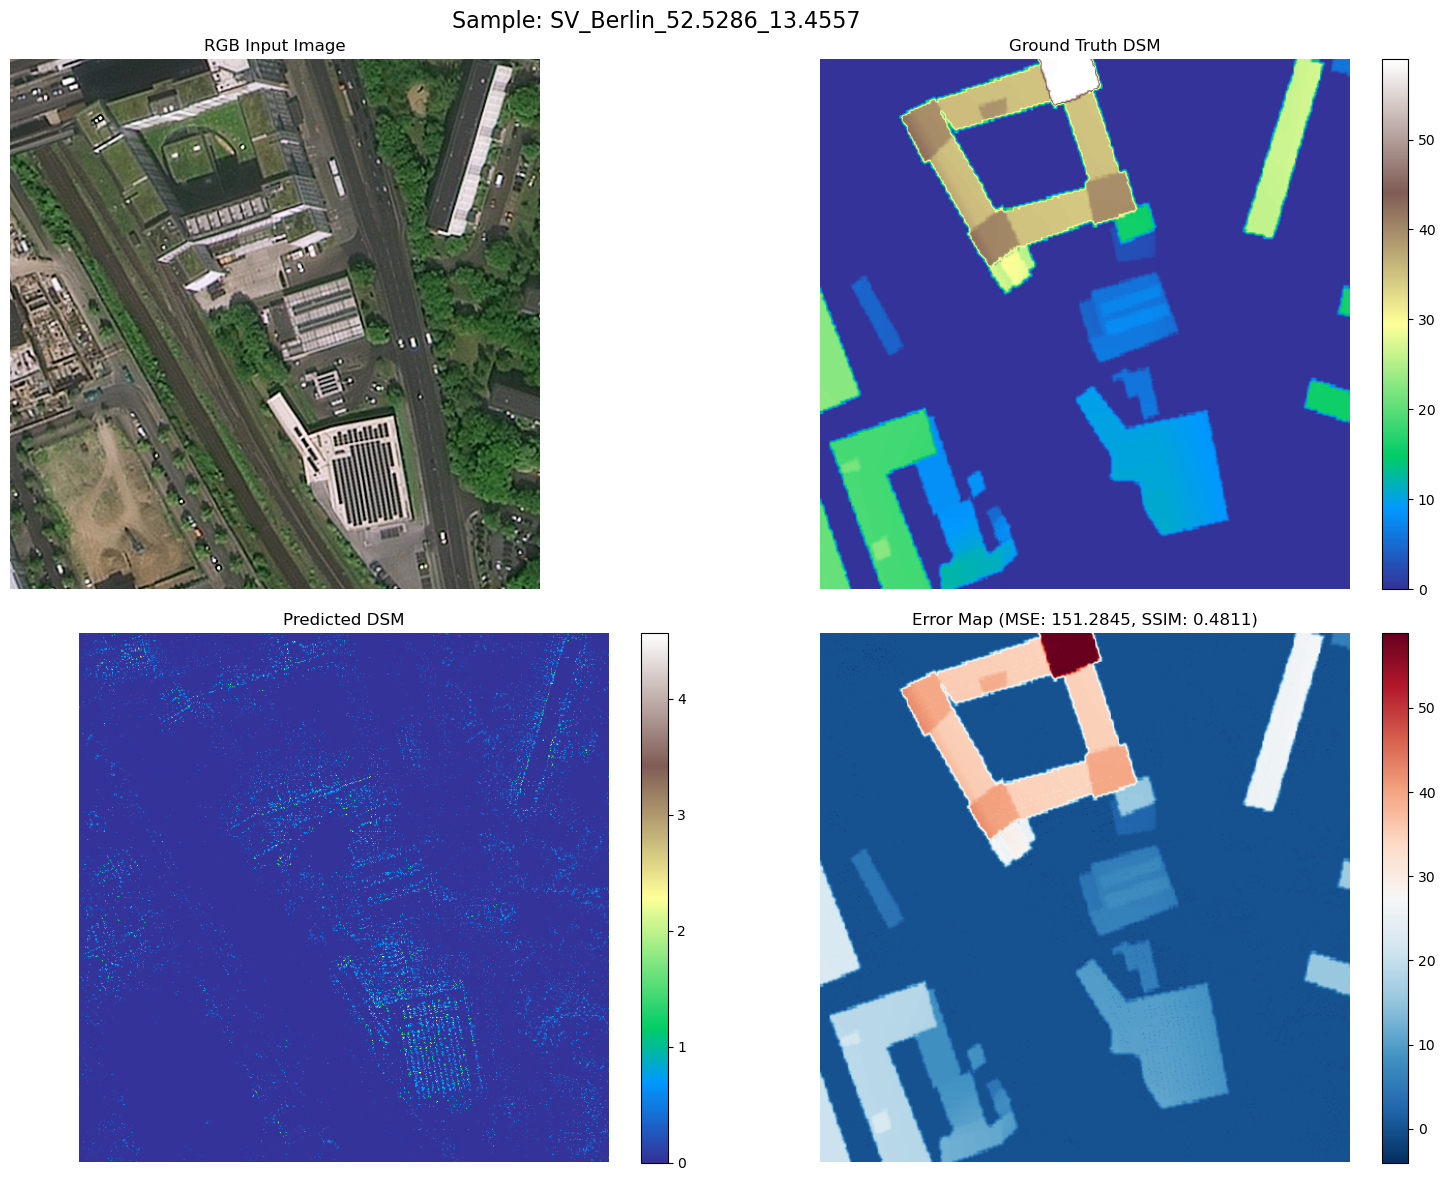

RGB shape: (512, 512, 3)
Ground truth DSM shape: (512, 512)
Predicted DSM shape: (512, 512)
Saved visualization to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/SV_Copenhagen_55.6800_12.5610_comparison.png


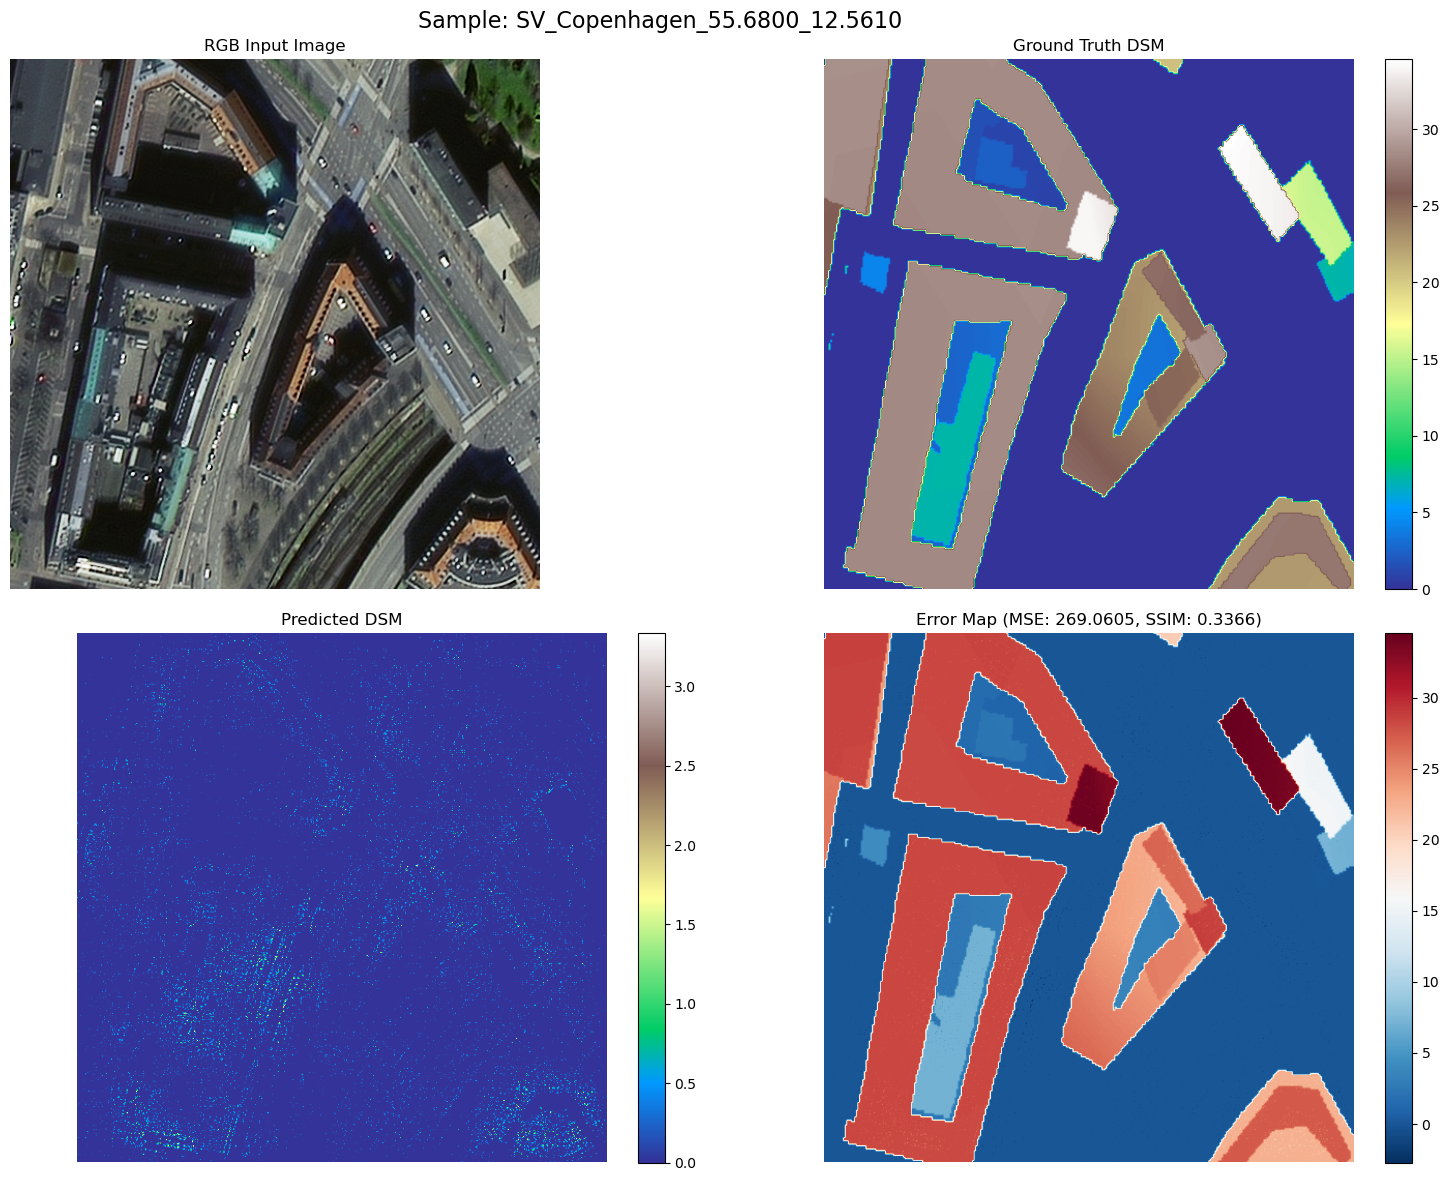

RGB shape: (512, 512, 3)
Ground truth DSM shape: (512, 512)
Predicted DSM shape: (512, 512)
Saved visualization to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/SV_Copenhagen_55.6941_12.5601_comparison.png


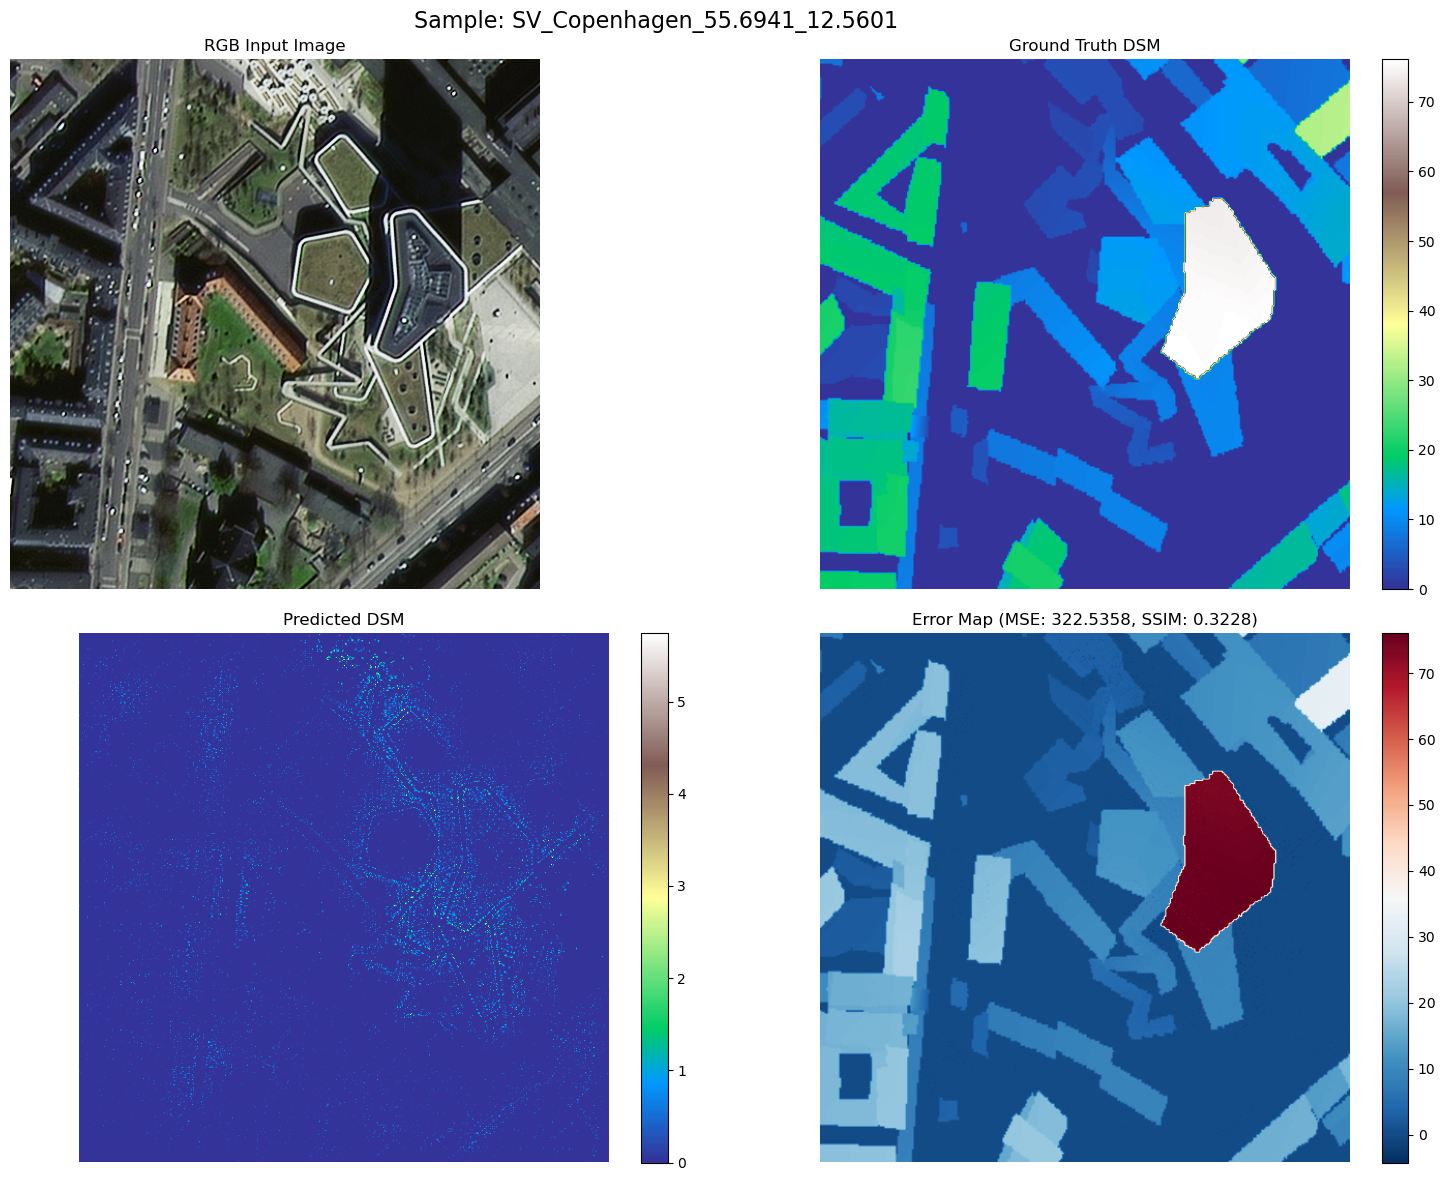

In [19]:
# Visualize the first 4 samples or all if there are fewer
num_samples_to_show = min(4, len(results))

for i in range(num_samples_to_show):
    result = results[i]
    fig = visualize_sample(
        result['rgb_img'], 
        result['gt_dsm'], 
        result['pred_dsm'], 
        result['sample_name']
    )
    plt.show()
    plt.close(fig)  # Close to free memory

## Statistical Analysis of Results

Let's calculate overall metrics across all test samples to evaluate the model's performance on the {dataset_name} dataset.

In [20]:
# Calculate metrics for all samples
metrics = []

for result in results:
    # Extract ground truth and prediction
    gt = result['gt_dsm'][0].numpy() if result['gt_dsm'].dim() > 2 else result['gt_dsm'].numpy()
    pred = result['pred_dsm'][0] if result['pred_dsm'].ndim > 2 else result['pred_dsm']
    
    # Ensure ground truth and prediction have the same shape
    if gt.shape != pred.shape:
        print(f"Sample {result['sample_name']}: Resizing prediction from {pred.shape} to match ground truth shape {gt.shape}")
        pred = resize_array(pred, gt.shape)
        
    # Calculate metrics
    try:
        mse = mean_squared_error(gt, pred)
        ssim_val = ssim(gt, pred, data_range=pred.max()-pred.min())
        
        metrics.append({
            'sample_name': result['sample_name'],
            'mse': mse,
            'ssim': ssim_val,
            'min_error': (gt - pred).min(),
            'max_error': (gt - pred).max(),
            'mean_error': np.mean(gt - pred)
        })
    except Exception as e:
        print(f"Error calculating metrics for sample {result['sample_name']}: {e}")
        # Add a row with NaN values
        metrics.append({
            'sample_name': result['sample_name'],
            'mse': float('nan'),
            'ssim': float('nan'),
            'min_error': float('nan'),
            'max_error': float('nan'),
            'mean_error': float('nan')
        })

# Display metrics as a table
import pandas as pd
metrics_df = pd.DataFrame(metrics)
print(f"Summary statistics for {dataset_name}:")
print(metrics_df.describe())

# Show individual sample metrics
metrics_df

Summary statistics for DFC2023Amini:
              mse      ssim  min_error  max_error  mean_error
count    8.000000  8.000000   8.000000   8.000000    8.000000
mean   104.225285  0.439596  -2.752762  29.610649    4.008769
std    129.022167  0.096396   0.913480  25.378139    3.563358
min      4.262288  0.322845  -4.235783   9.155963    0.818464
25%      6.296010  0.372711  -3.031846   9.926245    1.351848
50%     37.168933  0.440266  -2.607891  19.188330    2.463731
75%    180.728476  0.484337  -2.082305  40.642496    6.060015
max    322.535812  0.616943  -1.699113  76.106499   10.097501


,sample_name,mse,ssim,min_error,max_error,mean_error
0,SV_Berlin_52.5054_13.4804,62.300055,0.411340,-2.534425,24.143354,3.254458
1,SV_Berlin_52.5286_13.4557,151.284470,0.481139,-4.005573,58.924015,5.288563
2,SV_Copenhagen_55.6800_12.5610,269.060495,0.336643,-2.707271,34.548656,10.097501
3,SV_Copenhagen_55.6941_12.5601,322.535812,0.322845,-4.235783,76.106499,8.374369
4,SV_SanDiego_32.7123_-117.2427,12.037811,0.493932,-2.085325,14.233306,1.673004
5,SV_SanDiego_32.7151_-117.2506,5.890007,0.469192,-1.699113,9.155963,1.141995
6,SV_SanDiego_32.7275_-117.2434,4.262288,0.616943,-2.073246,9.807630,0.818464
7,SV_SanDiego_32.7289_-117.2451,6.431345,0.384734,-2.681357,9.965783,1.421799


In [21]:
# Save metrics to CSV for dataset variant comparison
csv_output_path = os.path.join(output_dir, f"{dataset_name}_metrics_summary.csv")
metrics_df.to_csv(csv_output_path, index=False)

# Save summary statistics to a separate CSV
summary_df = metrics_df.describe()
summary_csv_path = os.path.join(output_dir, f"{dataset_name}_metrics_summary_stats.csv")
summary_df.to_csv(summary_csv_path)

print(f"Saved metrics to {csv_output_path}")
print(f"Saved summary statistics to {summary_csv_path}")

Saved metrics to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/DFC2023Amini_metrics_summary.csv
Saved summary statistics to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/DFC2023Amini_metrics_summary_stats.csv


## Generate Height Profiles

Let's generate height profiles (cross-sections) to compare ground truth and predicted heights along a line through the center of the image.

In [22]:
def plot_height_profile(gt_dsm, pred_dsm, sample_name, direction='horizontal', save_fig=True):
    """
    Plot height profile along a line through the center of the image
    
    Args:
        gt_dsm: Ground truth DSM tensor or array
        pred_dsm: Predicted DSM array
        sample_name: Name of the sample for the figure title
        direction: 'horizontal' or 'vertical'
        save_fig: Whether to save the figure
    """
    # Extract channel 0 from ground truth DSM if it's multi-channel
    if isinstance(gt_dsm, torch.Tensor):
        gt_dsm_np = gt_dsm[0].numpy() if gt_dsm.dim() > 2 else gt_dsm.numpy()
    else:
        gt_dsm_np = gt_dsm[0] if gt_dsm.ndim > 2 else gt_dsm
    
    # Extract the height values from the prediction
    if pred_dsm.ndim > 2:
        pred_dsm_np = pred_dsm[0] if pred_dsm.shape[0] == 1 else pred_dsm
    else:
        pred_dsm_np = pred_dsm
        
    # Ensure ground truth and prediction have the same shape
    if gt_dsm_np.shape != pred_dsm_np.shape:
        print(f"Resizing prediction to match ground truth shape: {gt_dsm_np.shape}")
        pred_dsm_np = resize_array(pred_dsm_np, gt_dsm_np.shape)
        print(f"After resizing, predicted DSM shape: {pred_dsm_np.shape}")
    
    # Get the height and width
    h, w = gt_dsm_np.shape
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(12, 6))
    
    if direction == 'horizontal':
        # Get the middle row
        row_idx = h // 2
        gt_profile = gt_dsm_np[row_idx, :]
        pred_profile = pred_dsm_np[row_idx, :]
        x_vals = np.arange(w)
        x_label = 'Column'
        title_direction = 'Horizontal'
    else:  # vertical
        # Get the middle column
        col_idx = w // 2
        gt_profile = gt_dsm_np[:, col_idx]
        pred_profile = pred_dsm_np[:, col_idx]
        x_vals = np.arange(h)
        x_label = 'Row'
        title_direction = 'Vertical'
    
    # Plot the profiles
    ax.plot(x_vals, gt_profile, 'b-', label='Ground Truth', linewidth=2)
    ax.plot(x_vals, pred_profile, 'r--', label='Prediction', linewidth=2)
    ax.fill_between(x_vals, gt_profile, pred_profile, color='gray', alpha=0.3)
    
    # Add labels and title
    ax.set_xlabel(x_label)
    ax.set_ylabel('Height')
    ax.set_title(f'{title_direction} Height Profile for {sample_name}')
    ax.legend()
    ax.grid(True)
    
    # Save figure if requested
    if save_fig:
        output_path = os.path.join(output_dir, f"{sample_name}_{direction}_profile.png")
        plt.savefig(output_path, dpi=200, bbox_inches='tight')
        print(f"Saved height profile to {output_path}")
    
    return fig

Saved height profile to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/SV_Berlin_52.5054_13.4804_horizontal_profile.png


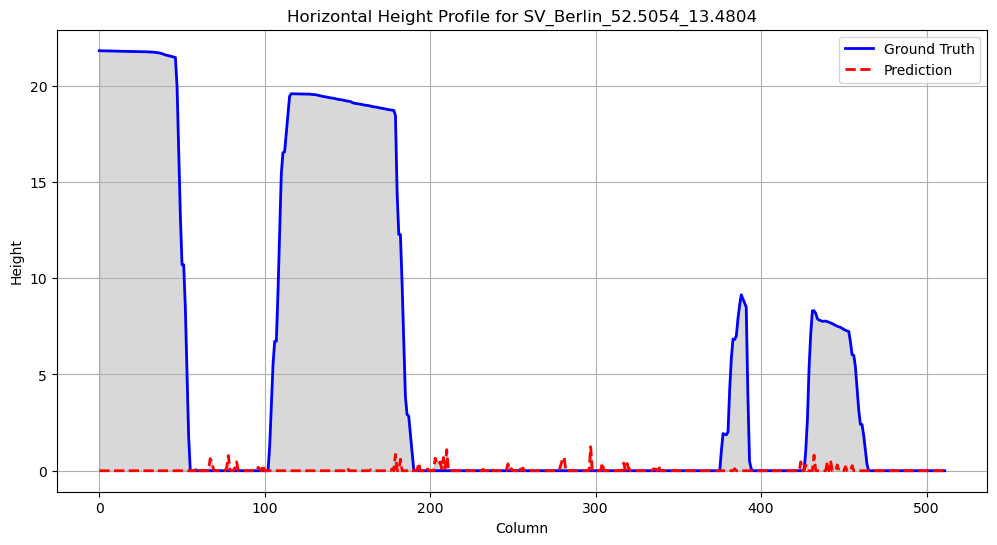

Saved height profile to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/SV_Berlin_52.5054_13.4804_vertical_profile.png


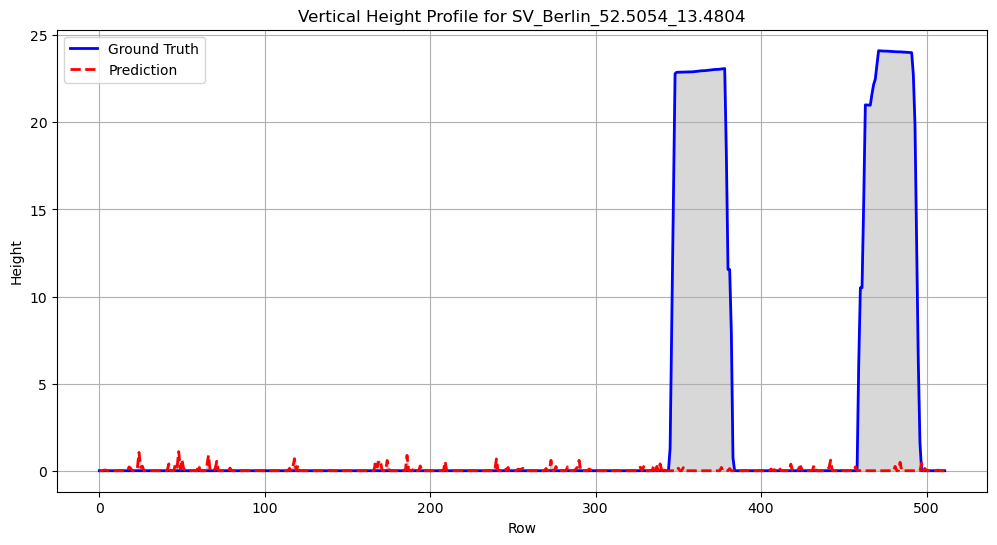

Saved height profile to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/SV_Berlin_52.5286_13.4557_horizontal_profile.png


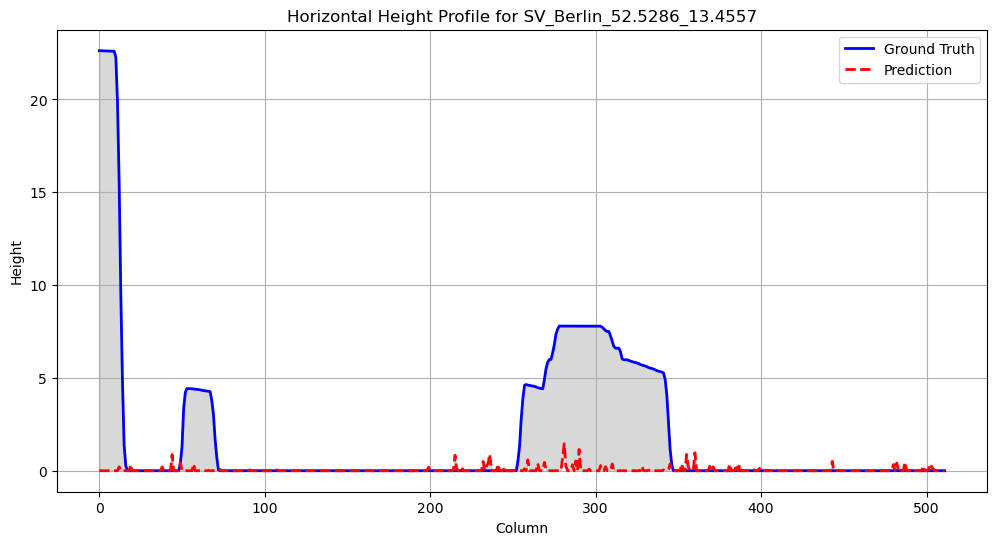

Saved height profile to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/SV_Berlin_52.5286_13.4557_vertical_profile.png


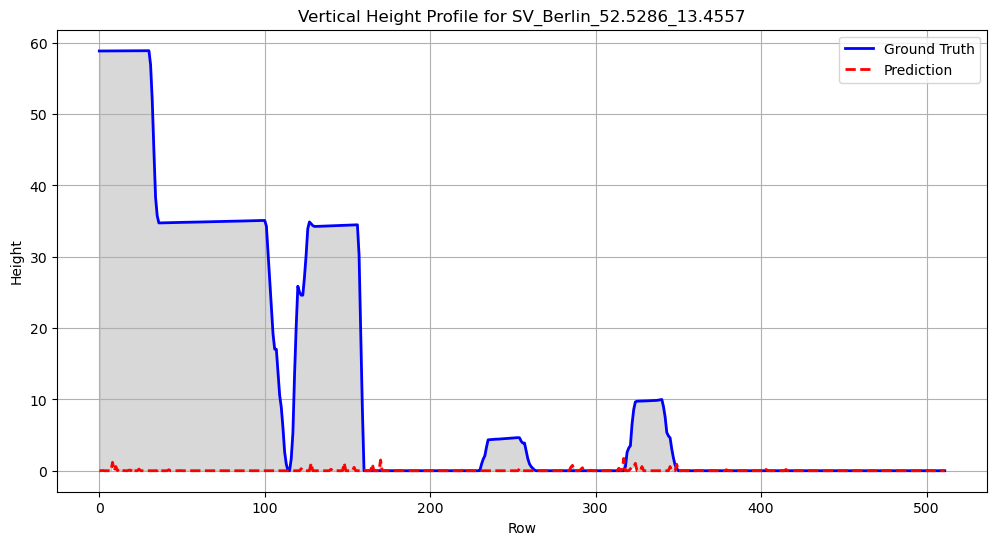

In [23]:
# Plot height profiles for the first 2 samples
for i in range(min(2, len(results))):
    result = results[i]
    
    # Horizontal profile
    fig_h = plot_height_profile(
        result['gt_dsm'],
        result['pred_dsm'],
        result['sample_name'],
        direction='horizontal'
    )
    plt.show()
    plt.close(fig_h)
    
    # Vertical profile
    fig_v = plot_height_profile(
        result['gt_dsm'],
        result['pred_dsm'],
        result['sample_name'],
        direction='vertical'
    )
    plt.show()
    plt.close(fig_v)

## 3D Surface Visualization

Let's create 3D surface plots to better visualize the height predictions.

In [24]:
def plot_3d_surface(gt_dsm, pred_dsm, sample_name, save_fig=True):
    """
    Create 3D surface plots of the ground truth and predicted DSM
    
    Args:
        gt_dsm: Ground truth DSM tensor or array
        pred_dsm: Predicted DSM array
        sample_name: Name of the sample for the figure title
        save_fig: Whether to save the figure
    """
    # Extract data
    if isinstance(gt_dsm, torch.Tensor):
        gt_dsm_np = gt_dsm[0].numpy() if gt_dsm.dim() > 2 else gt_dsm.numpy()
    else:
        gt_dsm_np = gt_dsm[0] if gt_dsm.ndim > 2 else gt_dsm
    
    if pred_dsm.ndim > 2:
        pred_dsm_np = pred_dsm[0] if pred_dsm.shape[0] == 1 else pred_dsm
    else:
        pred_dsm_np = pred_dsm
    
    # Ensure ground truth and prediction have the same shape
    if gt_dsm_np.shape != pred_dsm_np.shape:
        print(f"Resizing prediction to match ground truth shape for 3D visualization: {gt_dsm_np.shape}")
        pred_dsm_np = resize_array(pred_dsm_np, gt_dsm_np.shape)
        print(f"After resizing, predicted DSM shape: {pred_dsm_np.shape}")
    
    # For better visualization, downsample the data if it's too large
    h, w = gt_dsm_np.shape
    if h > 100 or w > 100:
        # Downsample to around 100x100
        downsample_factor = max(h // 100, w // 100, 1)
        gt_dsm_np = gt_dsm_np[::downsample_factor, ::downsample_factor]
        pred_dsm_np = pred_dsm_np[::downsample_factor, ::downsample_factor]
        print(f"Downsampled 3D surface by factor of {downsample_factor} to {gt_dsm_np.shape}")
    
    # Create x and y coordinates
    h, w = gt_dsm_np.shape
    x = np.arange(0, w)
    y = np.arange(0, h)
    X, Y = np.meshgrid(x, y)
    
    # Create figure with 3D subplots
    fig = plt.figure(figsize=(16, 8))
    
    # Ground truth surface
    ax1 = fig.add_subplot(121, projection='3d')
    surf1 = ax1.plot_surface(X, Y, gt_dsm_np, cmap=cm.terrain, 
                            linewidth=0, antialiased=True, alpha=0.8)
    ax1.set_title('Ground Truth DSM')
    
    # Predicted surface
    ax2 = fig.add_subplot(122, projection='3d')
    surf2 = ax2.plot_surface(X, Y, pred_dsm_np, cmap=cm.terrain, 
                           linewidth=0, antialiased=True, alpha=0.8)
    ax2.set_title('Predicted DSM')
    
    # Set the z range to be the same for both plots
    z_min = min(gt_dsm_np.min(), pred_dsm_np.min())
    z_max = max(gt_dsm_np.max(), pred_dsm_np.max())
    ax1.set_zlim(z_min, z_max)
    ax2.set_zlim(z_min, z_max)
    
    # Overall title
    plt.suptitle(f'3D Surface Plot for {sample_name}', fontsize=16)
    plt.tight_layout()
    
    # Add color bars
    fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
    fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)
    
    # Save figure if requested
    if save_fig:
        output_path = os.path.join(output_dir, f"{sample_name}_3d_surface.png")
        plt.savefig(output_path, dpi=200, bbox_inches='tight')
        print(f"Saved 3D surface plot to {output_path}")
    
    return fig

Downsampled 3D surface by factor of 5 to (103, 103)
Saved 3D surface plot to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/SV_Berlin_52.5054_13.4804_3d_surface.png


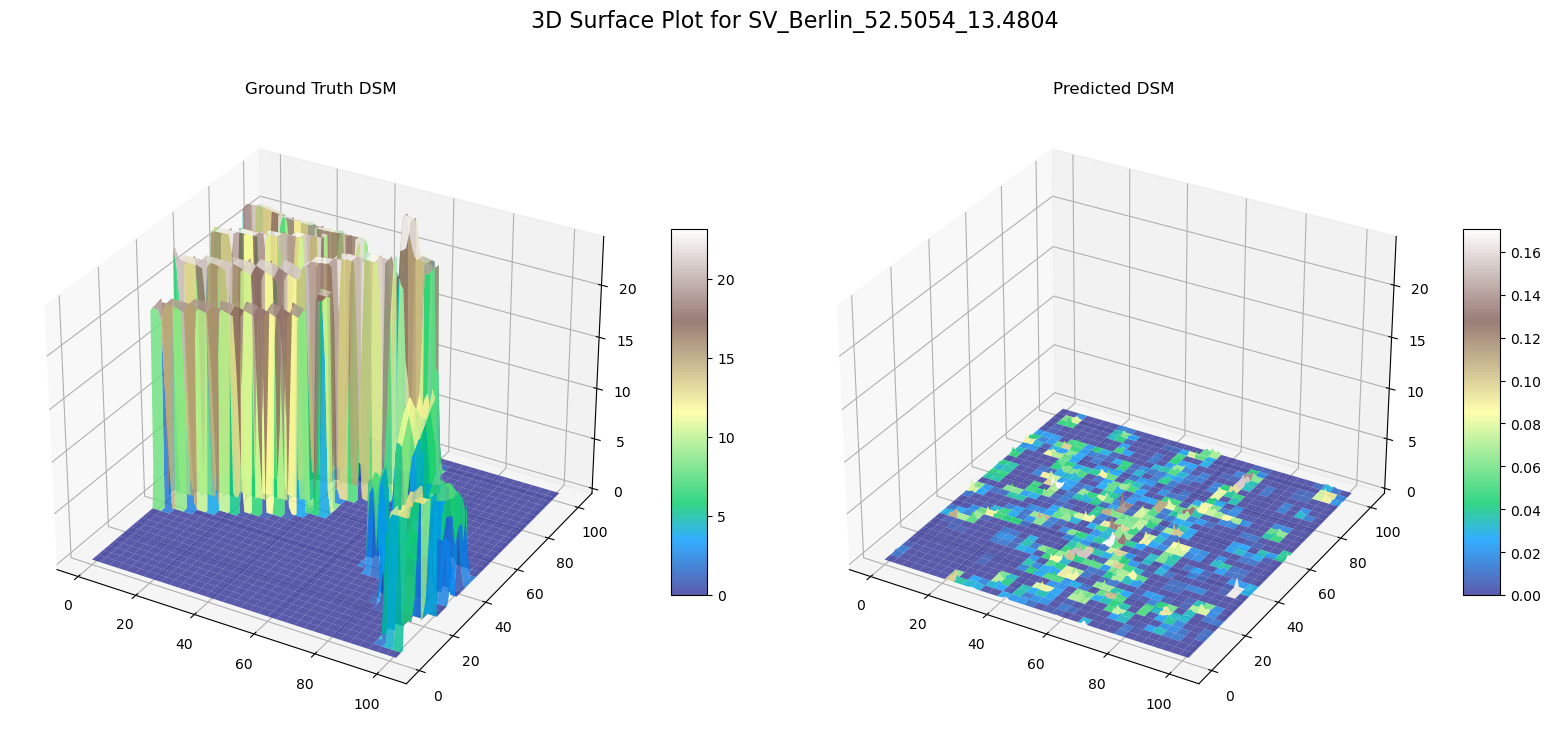

Downsampled 3D surface by factor of 5 to (103, 103)
Saved 3D surface plot to /home/asfand/Ahmad/IM2HEIGHT/tools/visualization_outputs/SV_Berlin_52.5286_13.4557_3d_surface.png


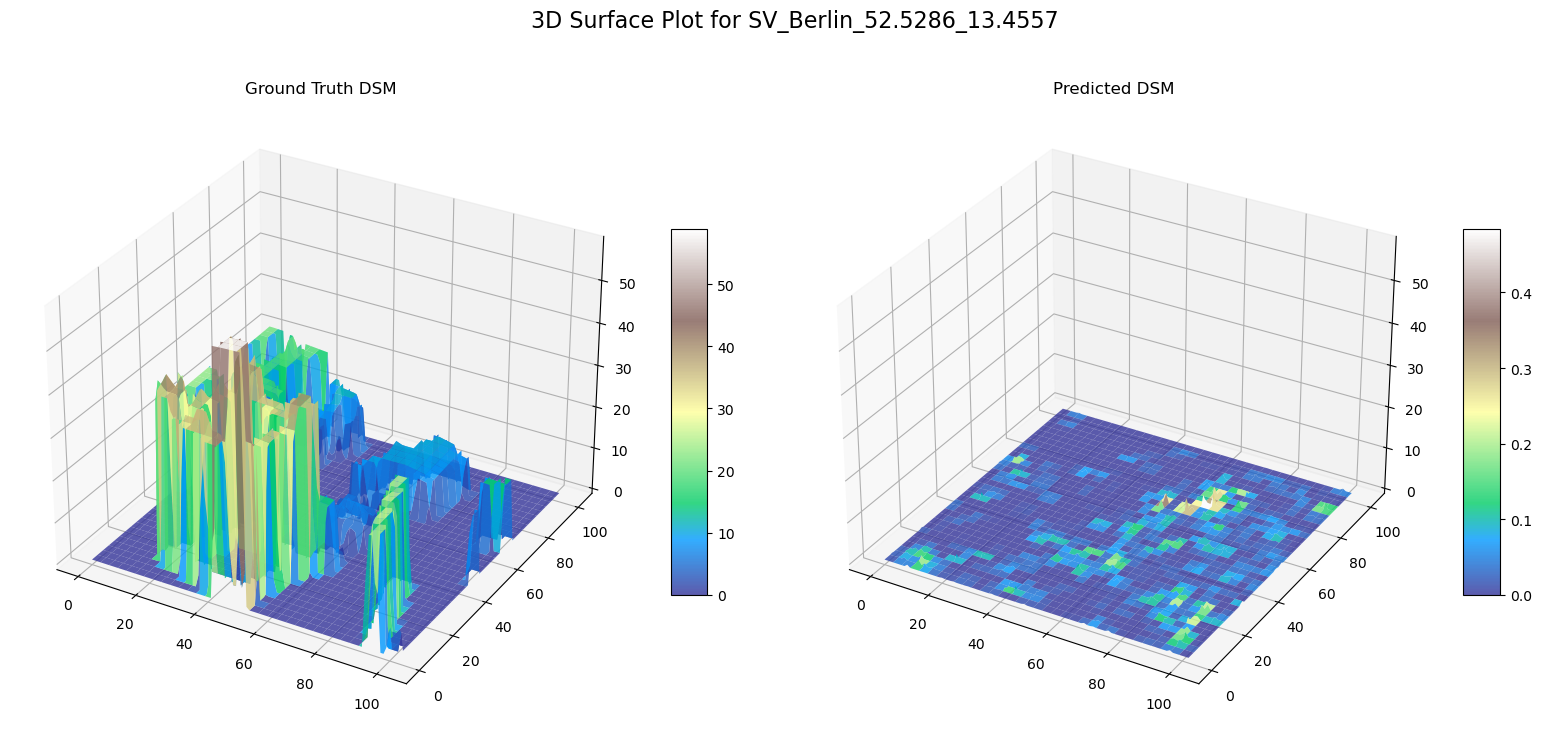

In [25]:
# Create 3D surface plots for the first 2 samples
for i in range(min(2, len(results))):
    result = results[i]
    fig_3d = plot_3d_surface(
        result['gt_dsm'],
        result['pred_dsm'],
        result['sample_name']
    )
    plt.show()
    plt.close(fig_3d)

## Summary and Conclusions

We've visualized several aspects of the IM2HEIGHT model's performance on the {dataset_name} dataset:

1. **2D Visualizations** showing input RGB, ground truth DSM, predicted DSM, and error maps
2. **Height Profiles** showing cross-sections through the center of the images
3. **3D Surface Plots** showing the overall terrain geometry
4. **Statistical Metrics** evaluating prediction accuracy

Key observations:
- The model generally captures major terrain features
- Error patterns show where the model struggles (may vary by sample)
- Structural similarity (SSIM) and MSE metrics quantify the accuracy

Areas for potential improvement:
- Fine-tuning the model for specific terrain types
- Increasing training data diversity
- Enhancing the network architecture

## Working with Different Dataset Variants

This notebook now supports easy analysis across different DFC2023 dataset variants:

1. **Dataset Configuration**: Change the `dataset_name` variable in the configuration cell to analyze a different dataset variant
2. **Dataset Analysis**: The notebook automatically checks dataset size and characteristics
3. **Metrics Export**: Performance metrics are saved to CSV files for each dataset variant
4. **Cross-Dataset Comparison**: After running analysis on multiple dataset variants, the comparison tools visualize performance differences

This makes it simple to analyze how model performance varies across different dataset variants while maintaining a consistent evaluation methodology.

In [26]:
# Compare with other dataset variants if available
def compare_dataset_variants():
    """Compare metrics across different dataset variants if CSV files exist"""
    variant_csvs = [f for f in os.listdir(output_dir) if f.endswith('_metrics_summary_stats.csv')]
    
    if len(variant_csvs) <= 1:
        print("No other dataset variants found for comparison.")
        return
    
    # Load all available variant summaries
    variant_dfs = {}
    for csv_file in variant_csvs:
        variant_name = csv_file.split('_metrics_summary_stats.csv')[0]
        try:
            df = pd.read_csv(os.path.join(output_dir, csv_file))
            # Use only mean metrics for comparison
            if 'mean' in df.index.astype(str).values:
                mean_row = df.loc['mean']
                variant_dfs[variant_name] = mean_row
        except Exception as e:
            print(f"Could not load {csv_file}: {e}")
    
    if not variant_dfs:
        print("Could not load any variant comparison data.")
        return
    
    # Create comparison dataframe
    comparison_df = pd.DataFrame(variant_dfs).T
    
    # Display comparison
    print("\nComparison of metrics across dataset variants:")
    display(comparison_df[[c for c in comparison_df.columns if c not in ['count', '25%', '50%', '75%', 'min', 'max']]])
    
    # Create bar chart comparison
    try:
        metrics_to_plot = ['mse', 'ssim']
        fig, axs = plt.subplots(1, len(metrics_to_plot), figsize=(12, 5))
        
        for i, metric in enumerate(metrics_to_plot):
            if metric in comparison_df.columns:
                comparison_df[metric].plot(kind='bar', ax=axs[i], title=f'{metric.upper()} by Dataset Variant')
                axs[i].set_ylabel(metric.upper())
                
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Could not create comparison charts: {e}")

# Run the comparison if we have data
try:
    compare_dataset_variants()
except Exception as e:
    print(f"Dataset comparison could not be performed: {e}")

No other dataset variants found for comparison.
